In [ ]:
import librosa
import numpy as np

y, sr = librosa.load("audio-feature-extractor/Data_Train_to_DB/cello/043__[cel][nod][cla]0029__1.wav", sr = 22050)

mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print(mfcc.shape)

spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
print(spectral_centroid.shape)

spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
print(spectral_bandwidth.shape)

spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
print(spectral_rolloff.shape)

spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
print(spectral_contrast.shape)

zcr = librosa.feature.zero_crossing_rate(y=y)
print(zcr.shape)

rms_energy = librosa.feature.rms(y=y)
print(rms_energy.shape)

mfcc_mean = np.mean(mfcc, axis=1)
spectral_centroid_mean = np.mean(spectral_centroid)
spectral_bandwidth_mean = np.mean(spectral_bandwidth)
spectral_rolloff_mean = np.mean(spectral_rolloff)
spectral_contrast_mean = np.mean(spectral_contrast)
zcr_mean = np.mean(zcr)
rms_energy_mean = np.mean(rms_energy)

feature_vector = np.concatenate([
    mfcc_mean,
    [spectral_centroid_mean],
    [spectral_bandwidth_mean],
    [spectral_rolloff_mean],
    [zcr_mean],
    [rms_energy_mean],
    [spectral_contrast_mean]
])
print(feature_vector)




(13, 130)
(1, 130)
(1, 130)
(1, 130)
(7, 130)
(1, 130)
(1, 130)
[-3.13370087e+02  1.39255554e+02 -5.67135887e+01  6.33813324e+01
  5.40929604e+00  8.69106352e-01 -1.39894152e+01 -4.60086584e-01
 -4.55719090e+00 -2.54832125e+00 -5.95243692e+00 -8.12742710e+00
 -7.40177584e+00  1.55306967e+03  1.47230608e+03  2.88279898e+03
  9.18907752e-02  2.47164760e-02  2.37668131e+01]


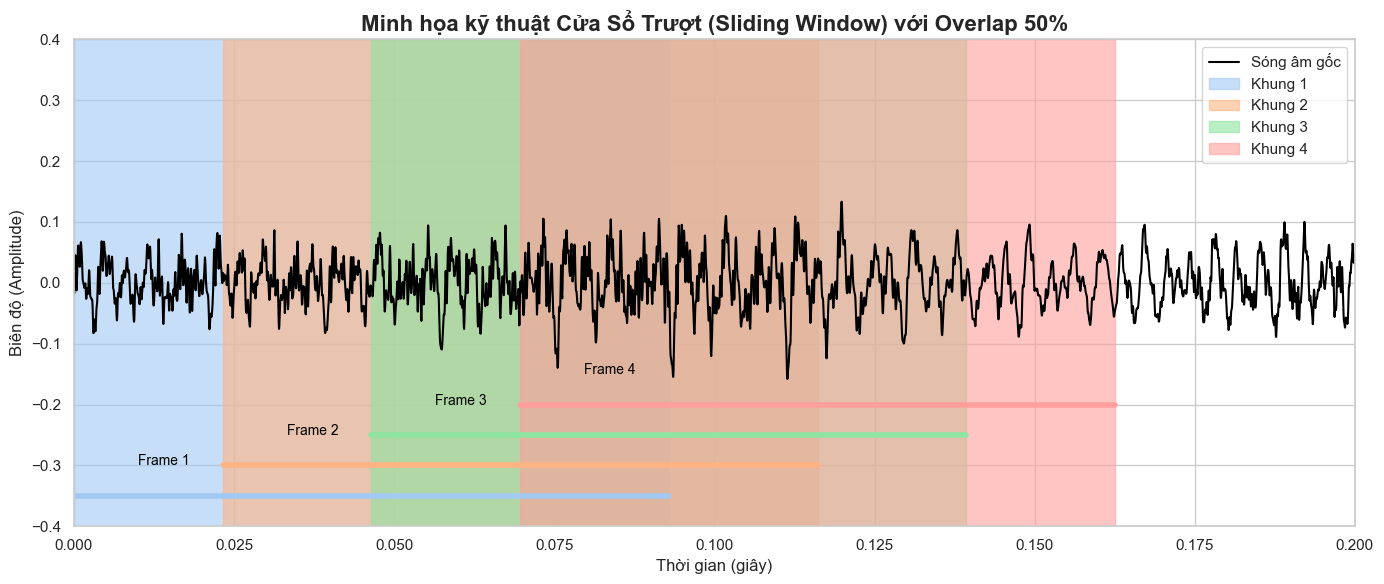

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Thiết lập giao diện biểu đồ đẹp mắt bằng Seaborn
sns.set_theme(style="whitegrid")

t = np.arange(len(y)) / sr
# 3. Cài đặt thông số cắt (Framing)
n_fft = 2048      # Kích thước 1 khung là 300 mẫu (tương đương 0.3 giây)
hop_length = 512  # Bước nhảy 150 mẫu (Tạo ra overlap 50% giữa các khung)

# 4. Bắt đầu vẽ biểu đồ
plt.figure(figsize=(14, 6))

# Vẽ đường sóng âm chính
sns.lineplot(x=t, y=y, color="black", linewidth=1.5, label="Sóng âm gốc")

# Lấy một bộ màu đẹp từ Seaborn để tô màu cho các khung
palette = sns.color_palette("pastel", 6)

# Vẽ minh họa 4 khung (frames) đầu tiên
for i in range(4):
    start_sample = i * hop_length
    end_sample = start_sample + n_fft
    
    # Đổi từ số thứ tự mẫu (sample) sang thời gian (giây) để khớp với trục x
    start_time = start_sample / sr
    end_time = end_sample / sr
    
    # Vẽ các vùng màu tương ứng với từng khung (Frame)
    plt.axvspan(start_time, end_time, color=palette[i], alpha=0.6, 
                label=f"Khung {i+1}")
    
    # Vẽ các đường gạch ngang ở dưới đáy để minh họa "Bước nhảy" (Hop Length) rõ hơn
    y_offset = -0.35 + (i * 0.05) # Xếp chồng các đường gạch lên nhau
    plt.plot([start_time, end_time], [y_offset, y_offset], color=palette[i], linewidth=4)
    plt.text(start_time + 0.01, y_offset + 0.05, f"Frame {i+1}", color='black', fontsize=10)

# 5. Căn chỉnh text và hiển thị
plt.title("Minh họa kỹ thuật Cửa Sổ Trượt (Sliding Window) với Overlap 50%", fontsize=16, fontweight='bold')
plt.xlabel("Thời gian (giây)", fontsize=12)
plt.ylabel("Biên độ (Amplitude)", fontsize=12)
plt.xlim(0, 0.2)
plt.ylim(-0.4, 0.4)
plt.legend(loc='upper right')
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()